In [ ]:
import numpy as np
from scipy import stats

# Generating two random samples from different distributions
np.random.seed(42)  # for reproducibility
sample1 = np.random.normal(0.5, 1.3, 1000)  # Sample 1: Normal distribution with mean 0 and std 1
sample2 = np.random.normal(0.5, 1.5, 1000)  # Sample 2: Normal distribution with mean 0.5 and std 1.5

# Performing the two-sample Kolmogorov-Smirnov test
ks_statistic, p_value = stats.ks_2samp(sample1, sample2)

# Displaying the results
print(f'K-S Statistic: {ks_statistic}')
print(f'p-value: {p_value}')

K-S Statistic: 0.066
p-value: 0.025633868930359294


TypeError: expected x and y to have same length

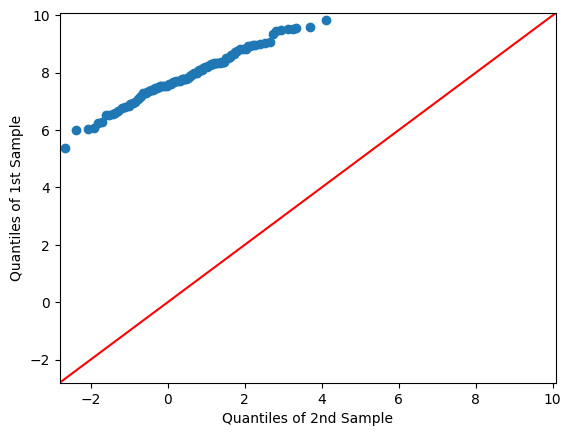

In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Generar dos muestras aleatorias de diferentes distribuciones
np.random.seed(42)
sample1 = np.random.normal(8, 1, 100)  # Distribución normal con media 0 y desviación estándar 1
sample2 = np.random.normal(0.5, 1.5, 1000)  # Distribución normal con media 0.5 y desviación estándar 1.5

# Crear el gráfico Q-Q
fig = sm.qqplot_2samples(sample1, sample2, line='45')

# Extraer los cuantiles de ambas muestras para el cálculo de pendiente e intercepto
sample1_quantiles = np.sort(sample1)
sample2_quantiles = np.sort(sample2)

# Regresión lineal para obtener la pendiente y el intercepto
slope, intercept = np.polyfit(sample1_quantiles, sample2_quantiles, 1)

# Calcular la distancia desde la línea de 45 grados utilizando el error cuadrático medio (MSE)
expected_line = slope * sample1_quantiles + intercept
mse = np.mean((expected_line - sample2_quantiles)**2)

# Mostrar el gráfico y devolver pendiente, intercepto y MSE
plt.title("Gráfico Q-Q de dos distribuciones")
plt.show()

print(f"Pendiente: {slope}")
print(f"Intercepto: {intercept}")
print(f"Error Cuadrático Medio (MSE): {mse}")

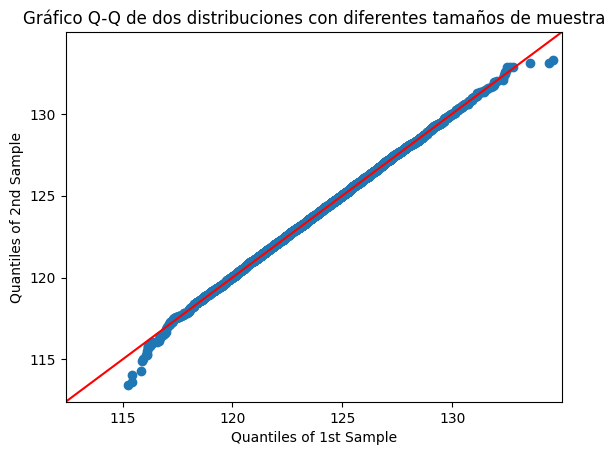

Pendiente: 0.9982711336707548
Intercepto: 0.25060765420957365
Error Cuadrático Medio (MSE): 0.0043100316572804625


In [ ]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Generar dos muestras aleatorias de diferentes distribuciones y tamaños diferentes
np.random.seed(42)
sample1 = np.random.normal(124, 2.7
, 7000)  # Distribución normal con media 0 y desviación estándar 1
sample2 = np.random.normal(124, 2.7, 7000)  # Distribución normal con media 0.5 y desviación estándar 1.5

# Crear el gráfico Q-Q con tamaños de muestra diferentes
fig = sm.qqplot_2samples(sample1, sample2, line='45')

# Calcular los cuantiles en función de la longitud de las muestras
quantiles1 = np.linspace(0, 1, len(sample1))
quantiles2 = np.linspace(0, 1, len(sample2))

# Interpolar los cuantiles para igualar los tamaños de las muestras
sample2_interp = np.interp(quantiles1, quantiles2, np.sort(sample2))

# Regresión lineal para obtener la pendiente y el intercepto
slope, intercept = np.polyfit(np.sort(sample1), sample2_interp, 1)

# Calcular la distancia desde la línea de 45 grados utilizando el error cuadrático medio (MSE)
expected_line = slope * np.sort(sample1) + intercept
mse = np.mean((expected_line - sample2_interp)**2)

# Mostrar el gráfico y devolver pendiente, intercepto y MSE
plt.title("Gráfico Q-Q de dos distribuciones con diferentes tamaños de muestra")
plt.show()

print(f"Pendiente: {slope}")
print(f"Intercepto: {intercept}")
print(f"Error Cuadrático Medio (MSE): {mse}")

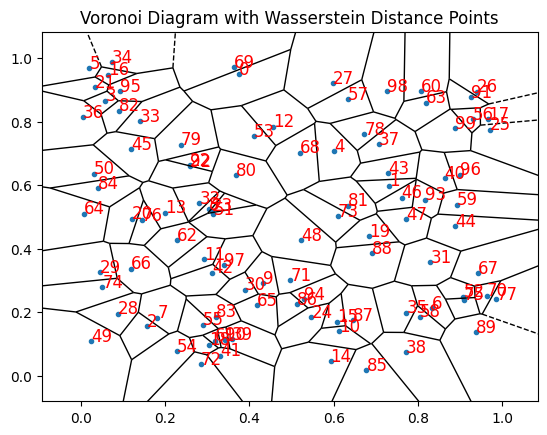

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
from sklearn.neighbors import NearestNeighbors
from scipy.spatial import Voronoi, voronoi_plot_2d

# Generate random points representing locations of distributions
np.random.seed(42)
points = np.random.rand(100, 2)  # 10 random points in 2D space

# Generate random 1D distributions for each point using the first component as the mean
distributions = [np.random.normal(loc=point[0], scale=0.1, size=1000) for point in points]

# Calculate pairwise Wasserstein distances between distributions
distances = np.zeros((len(distributions), len(distributions)))

for i in range(len(distributions)):
    for j in range(len(distributions)):
        distances[i, j] = wasserstein_distance(distributions[i], distributions[j])

# Perform Voronoi diagram based on points
vor = Voronoi(points)

# Plot Voronoi diagram
fig, ax = plt.subplots()
voronoi_plot_2d(vor, ax=ax, show_vertices=False)

# Annotate points with Wasserstein distances
for i, point in enumerate(points):
    ax.text(point[0], point[1], f'{i}', fontsize=12, color='red')

plt.title("Voronoi Diagram with Wasserstein Distance Points")
plt.show()

<ipython-input-7-4fcf194fac63>:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('tab20', n_groups)


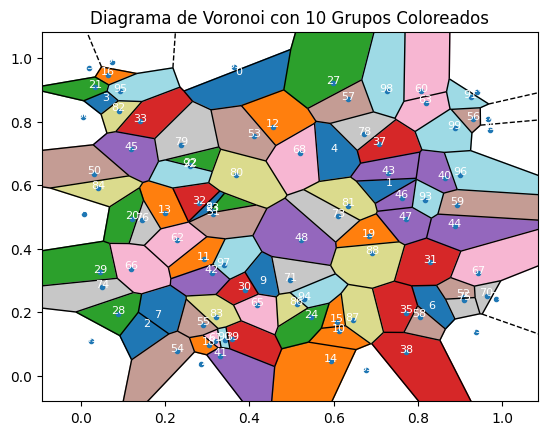

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d
import matplotlib.cm as cm

# Generar puntos aleatorios que representan ubicaciones de distribuciones
np.random.seed(42)
points = np.random.rand(100, 2)  # 50 puntos aleatorios en un espacio 2D

# Crear el diagrama de Voronoi basado en los puntos
vor = Voronoi(points)

# Dividir los puntos en n grupos (ejemplo: 5 grupos)
n_groups = 10
group_indices = np.array_split(np.arange(len(points)), n_groups)

# Generar un mapa de colores
colors = cm.get_cmap('tab20', n_groups)

# Graficar el diagrama de Voronoi con diferentes colores para cada grupo
fig, ax = plt.subplots()
voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='black')

# Colorear las regiones del diagrama de Voronoi según el grupo al que pertenece cada punto
for i, group in enumerate(group_indices):
    for index in group:
        region = vor.regions[vor.point_region[index]]
        if not -1 in region:  # Saltar regiones que se extienden hacia el infinito
            polygon = [vor.vertices[i] for i in region]
            ax.fill(*zip(*polygon), color=colors(i))

# Anotar los puntos con el número de grupo al que pertenecen
for i, point in enumerate(points):
    ax.text(point[0], point[1], f'{i}', fontsize=8, ha='center', color='white')

plt.title(f"Diagrama de Voronoi con {n_groups} Grupos Coloreados")
plt.show()